# 03 — Signals Demo: Classical vs ML

This notebook compares classical arbitrage signaling outputs against actual ML signal strategy outputs, with advanced-method diagnostics shown separately.

In [14]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
TABLES = ROOT / 'project report' / 'tables'
PROCESSED = ROOT / 'data' / 'processed'

signals_path = PROCESSED / 'signals_latest.csv'
snapshot_path = PROCESSED / 'signals_latest_snapshot.csv'
diag_path = PROCESSED / 'signals_latest_diagnostics.csv'
adv_path = TABLES / 'tab_6_4_advanced_methods.csv'
pf_path = PROCESSED / 'portfolio_backtest_summary.csv'

ml_sig_path = PROCESSED / 'ml_signals.csv'
ml_snap_path = PROCESSED / 'ml_signals_snapshot.csv'
ml_diag_path = PROCESSED / 'ml_signals_diagnostics.csv'
ml_rel_path = PROCESSED / 'ml_signals_reliability.csv'
ml_st_path = PROCESSED / 'ml_signals_stability.csv'
ml_dec_path = PROCESSED / 'ml_signals_decisions.csv'
ml_pf_path = PROCESSED / 'ml_backtest_summary.csv'
regime_summary_path = PROCESSED / 'regime_backtest_summary.csv'
regime_router_path = PROCESSED / 'regime_router_decisions.csv'
regime_labels_path = PROCESSED / 'regime_labels_monthly.csv'
unified_summary_path = PROCESSED / 'unified_backtest_summary.csv'
unified_inf_path = PROCESSED / 'unified_backtest_inference.csv'

required = [
    signals_path, snapshot_path, diag_path, adv_path, pf_path,
    ml_sig_path, ml_snap_path, ml_diag_path, ml_rel_path, ml_st_path, ml_dec_path, ml_pf_path,
    regime_summary_path, regime_router_path, regime_labels_path,
    unified_summary_path, unified_inf_path
]
missing = [p for p in required if not p.exists()]
print(f'Missing artifacts: {len(missing)}')
for p in missing:
    print(' -', p)

if missing:
    display(Markdown('**Some artifacts are missing. Run `00_cache_and_run_control.ipynb` in full mode to regenerate.**'))

Missing artifacts: 0


## Labeling Assumptions and Target Construction

Signal labels are generated with triple-barrier logic (profit/stop/time) and a meta-labeling split between opportunity detection and direction prediction. This reduces noisy one-threshold labels but does not remove all model risk.

## Evidence-First Sequence

This notebook follows a conservative interpretation order:
1. Target construction and labeling assumptions.
2. Calibration evidence (Brier/reliability bins).
3. Stability evidence (threshold/cost sensitivity).
4. Decision logic evidence (reason codes, no-trade diagnostics).

### Claim Policy
- **Supported by statistical evidence**: robust across inference and stability checks.
- **Economically promising but not statistically strong**: positive economics with weak/uncertain inference.
- **Exploratory / not used for headline claims**: diagnostics and prototypes for further testing.

In [15]:
signals = pd.read_csv(signals_path, parse_dates=['date']) if signals_path.exists() else pd.DataFrame()
snapshot = pd.read_csv(snapshot_path) if snapshot_path.exists() else pd.DataFrame()
diag = pd.read_csv(diag_path) if diag_path.exists() else pd.DataFrame()
adv = pd.read_csv(adv_path) if adv_path.exists() else pd.DataFrame()
pf = pd.read_csv(pf_path) if pf_path.exists() else pd.DataFrame()

ml_signals = pd.read_csv(ml_sig_path, parse_dates=['date']) if ml_sig_path.exists() else pd.DataFrame()
ml_snapshot = pd.read_csv(ml_snap_path) if ml_snap_path.exists() else pd.DataFrame()
ml_diag = pd.read_csv(ml_diag_path) if ml_diag_path.exists() else pd.DataFrame()
ml_rel = pd.read_csv(ml_rel_path) if ml_rel_path.exists() else pd.DataFrame()
ml_st = pd.read_csv(ml_st_path) if ml_st_path.exists() else pd.DataFrame()
ml_dec = pd.read_csv(ml_dec_path, parse_dates=['date']) if ml_dec_path.exists() else pd.DataFrame()
ml_pf = pd.read_csv(ml_pf_path) if ml_pf_path.exists() else pd.DataFrame()
regime_summary = pd.read_csv(regime_summary_path) if regime_summary_path.exists() else pd.DataFrame()
regime_router = pd.read_csv(regime_router_path) if regime_router_path.exists() else pd.DataFrame()
regime_labels = pd.read_csv(regime_labels_path, parse_dates=['date']) if regime_labels_path.exists() else pd.DataFrame()
unified = pd.read_csv(unified_summary_path) if unified_summary_path.exists() else pd.DataFrame()
unified_inf = pd.read_csv(unified_inf_path) if unified_inf_path.exists() else pd.DataFrame()

display(Markdown('## Latest Classical Snapshot'))
display(snapshot)

display(Markdown('## Latest ML Snapshot'))
display(ml_snapshot)

display(Markdown('## Classical Signal Diagnostics'))
display(diag)

display(Markdown('## ML Signal Diagnostics'))
display(ml_diag)

display(Markdown('## ML Reliability (Calibration Bins)'))
display(ml_rel)

display(Markdown('## ML Stability (Threshold Sensitivity)'))
display(ml_st)

display(Markdown('## Monthly ML Decision Table (trade/no-trade + reasons)'))
display(ml_dec.tail(24))

display(Markdown('## Unified Backtest Summary (statistically aligned comparison)'))
display(unified)

display(Markdown('## Unified Inference (CI and paired test)'))
display(unified_inf)

display(Markdown('## Regime Backtest Summary (model vs regime)'))
display(regime_summary)

display(Markdown('## Router Decisions by Regime Cell'))
display(regime_router)

display(Markdown('## Portfolio Summary (Classical)'))
display(pf)

display(Markdown('## Portfolio Summary (ML)'))
display(ml_pf)

display(Markdown('## Advanced Method Diagnostics (non-trading diagnostic block)'))
display(adv)

## Latest Classical Snapshot

,timestamp,signal_type,maturity_bucket,direction,strength,confidence
0,2026-05-23T18:13:43Z,spread,3M,0,1.4400,0.4800
1,2026-05-23T18:13:43Z,cip,3M,0,0.9400,0.3133
2,2026-05-23T18:13:43Z,spread,6M,0,1.3500,0.4500
3,2026-05-23T18:13:43Z,cip,6M,0,0.9900,0.3300
4,2026-05-23T18:13:43Z,spread,1Y,0,1.1400,0.3800
5,2026-05-23T18:13:43Z,cip,1Y,0,1.0600,0.3533
6,2026-05-23T18:13:43Z,spread,2Y,0,0.7900,0.2633
7,2026-05-23T18:13:43Z,cip,2Y,0,1.1400,0.3800
8,2026-05-23T18:13:43Z,spread,3Y,0,0.5400,0.1800
9,2026-05-23T18:13:43Z,cip,3Y,0,1.1800,0.3933


## Latest ML Snapshot

,timestamp,signal_type,maturity_bucket,direction,strength,confidence,proba_ensemble
0,2026-05-25T16:24:16.363956Z,ml,10Y_rel,0,0.111881,0.111881,0.44406


## Classical Signal Diagnostics

...

,strategy,ann_return,ann_vol,ann_sharpe,ann_sortino,calmar,cagr,total_return,max_drawdown,var95_empirical,var95_parametric,mean_return,hit_ratio,active_pct,ann_turnover,avg_turnover,total_cost_drag,benchmark,excess_ann_return_vs_benchmark,sharpe_delta_vs_benchmark
0,strategy,-0.004029,0.012861,-0.3133,-0.3306,-0.0678,-0.004104,-0.032362,-0.0605,0.0061,0.0061,-0.000336,0.4583,0.7083,0.4391,0.036589,0.001756,naive_50_50,-0.000883,-0.0226
1,naive_50_50,-0.003146,0.010823,-0.2907,-0.3207,-0.0614,-0.003199,-0.025309,-0.0521,0.0053,0.0051,-0.000262,0.4479,1.0000,0.0000,0.000000,0.000000,naive_50_50,0.000000,0.0000
2,disconnected_60_40,-0.004292,0.012794,-0.3354,-0.3721,-0.0690,-0.004364,-0.034385,-0.0633,0.0063,0.0061,-0.000358,0.4375,1.0000,0.0000,0.000000,0.000000,naive_50_50,-0.001146,-0.0447


## Portfolio Summary (ML)

,strategy,ann_return,ann_vol,ann_sharpe,ann_sortino,calmar,cagr,total_return,max_drawdown,var95_empirical,var95_parametric,mean_return,hit_ratio,active_pct,ann_turnover,avg_turnover,total_cost_drag,benchmark,excess_ann_return_vs_benchmark,sharpe_delta_vs_benchmark
0,ml_strategy,0.002514,0.017185,0.1463,0.1597,0.0671,0.002373,0.006938,-0.0353,0.0093,0.0082,0.000210,0.2857,0.5143,4.8000,0.400000,0.0070,ml_passive_spread,0.019487,0.9568
1,ml_passive_spread,-0.016973,0.020940,-0.8105,-1.1588,-0.2530,-0.017051,-0.048925,-0.0674,0.0114,0.0099,-0.001414,0.3429,1.0000,0.3429,0.028571,0.0005,ml_passive_spread,0.000000,0.0000


## Advanced Method Diagnostics (non-trading diagnostic block)

,Method,Metric,Value,Notes
0,NS_baseline,RMSE_mean,0.141584,In-sample overall RMSE
1,AER_proxy,Objective_mean,0.025394,MSE + lambda * curvature penalty
2,AER_proxy,Penalty_mean,0.018732,Average curvature smoothness penalty
3,Regime_DNS,1step_RMSE_last,0.251929,Status=fitted; macro=global_indicators_DGS10


## Interpretation Limits

- Reliability and stability tables are diagnostic evidence, not standalone proof of persistent alpha.
- Decision reason codes improve operator transparency but do not guarantee better out-of-sample profitability.
- Any economic claim should be cross-checked with unified inference and cost sensitivity artifacts.

In [16]:
# Build a statistically aligned comparison table from unified artifacts
adv_metric = dict(zip(adv['Metric'], adv['Value'])) if not adv.empty and {'Metric', 'Value'}.issubset(adv.columns) else {}

if unified.empty:
    comparison = pd.DataFrame()
else:
    keep_cols = [c for c in [
        'family', 'strategy', 'benchmark', 'ann_return', 'ann_vol', 'ann_sharpe',
        'ann_sortino', 'cagr', 'total_return', 'max_drawdown', 'var95_empirical',
        'active_pct', 'ann_turnover', 'total_cost_drag',
        'excess_ann_return_vs_benchmark', 'sharpe_delta_vs_benchmark'
    ] if c in unified.columns]
    comparison = unified[keep_cols].copy()

if not comparison.empty:
    display(Markdown('## Statistically Aligned Classical vs ML Table (Unified Backtest)'))
    display(comparison)

if not unified_inf.empty:
    display(Markdown('## Significance Layer (Bootstrap CI + Paired t-test)'))
    display(unified_inf)

# Keep advanced methods visible, but separate from tradable strategy comparisons.
adv_view = pd.DataFrame([
    {
        'Model_family': 'ML_like diagnostics (AER proxy + regime DNS)',
        'Diagnostic_metric': 'Objective_mean',
        'Value': adv_metric.get('Objective_mean', np.nan)
    }
])
display(Markdown('## Advanced Diagnostics (non-trading reference only)'))
display(adv_view)

## Statistically Aligned Classical vs ML Table (Unified Backtest)

,family,strategy,benchmark,ann_return,ann_vol,ann_sharpe,ann_sortino,cagr,total_return,max_drawdown,var95_empirical,active_pct,ann_turnover,total_cost_drag,excess_ann_return_vs_benchmark,sharpe_delta_vs_benchmark
0,classical,strategy,naive_50_50,-0.004029,0.012861,-0.3133,-0.3306,-0.004104,-0.032362,-0.0605,0.0061,0.7083,0.4391,0.001756,-0.000883,-0.0226
1,classical,naive_50_50,naive_50_50,-0.003146,0.010823,-0.2907,-0.3207,-0.003199,-0.025309,-0.0521,0.0053,1.0000,0.0000,0.000000,0.000000,0.0000
2,classical,disconnected_60_40,naive_50_50,-0.004292,0.012794,-0.3354,-0.3721,-0.004364,-0.034385,-0.0633,0.0063,1.0000,0.0000,0.000000,-0.001146,-0.0447
3,ml,ml_strategy,ml_passive_spread,0.002514,0.017185,0.1463,0.1597,0.002373,0.006938,-0.0353,0.0093,0.5143,4.8000,0.007000,0.019487,0.9568
4,ml,ml_passive_spread,ml_passive_spread,-0.016973,0.020940,-0.8105,-1.1588,-0.017051,-0.048925,-0.0674,0.0114,1.0000,0.3429,0.000500,0.000000,0.0000
5,regime_router,CL_PANEL,PASSIVE_SPREAD,-0.005523,0.010254,-0.5386,-0.5269,-0.005560,-0.026590,-0.0311,0.0051,0.6897,1.3190,0.003188,0.011015,0.1204
6,regime_router,CL_SPREAD,PASSIVE_SPREAD,-0.005523,0.010254,-0.5386,-0.5269,-0.005560,-0.026590,-0.0311,0.0051,0.6897,1.3190,0.003188,0.011015,0.1204
7,regime_router,ML_ENS,PASSIVE_SPREAD,0.002514,0.017185,0.1463,0.1597,0.002373,0.006938,-0.0353,0.0093,0.5143,4.8000,0.007000,0.019487,0.9568
8,regime_router,ML_LOGIT,PASSIVE_SPREAD,-0.015913,0.019864,-0.8011,-1.0620,-0.015987,-0.045917,-0.0593,0.0113,0.8286,6.5143,0.009500,0.001060,0.0094
9,regime_router,ML_RF,PASSIVE_SPREAD,-0.004160,0.019310,-0.2154,-0.2885,-0.004333,-0.012585,-0.0503,0.0093,0.8000,6.5143,0.009500,0.012813,0.5951


## Significance Layer (Bootstrap CI + Paired t-test)

,comparison,mean_return_diff,mean_diff_ci_low,mean_diff_ci_high,sharpe_diff,sharpe_diff_ci_low,sharpe_diff_ci_high,paired_t_stat,paired_t_pvalue,n_obs,cost_bps,family,regime_id,regime_cell,model_id
0,strategy_vs_naive_50_50,-0.000074,-0.000215,0.000062,-0.022633,-0.095669,0.058862,-1.024579,0.308164,96,5.0,classical,NaN,NaN,NaN
1,ml_strategy_vs_passive,0.001624,-0.001342,0.004706,0.956836,-0.912522,3.000375,1.055266,0.298745,35,5.0,ml,NaN,NaN,NaN
2,CL_PANEL_vs_PASSIVE_SPREAD,0.000918,-0.000241,0.002275,0.120407,-0.335717,0.732331,1.421749,0.160548,58,5.0,regime_router,regime_R1,R1_high_spread,CL_PANEL
3,CL_SPREAD_vs_PASSIVE_SPREAD,0.000918,-0.000241,0.002275,0.120407,-0.335717,0.732331,1.421749,0.160548,58,5.0,regime_router,regime_R1,R1_high_spread,CL_SPREAD
4,ML_ENS_vs_PASSIVE_SPREAD,0.001624,-0.001342,0.004706,0.956836,-0.912522,3.000375,1.055266,0.298745,35,5.0,regime_router,regime_R1,R1_high_spread,ML_ENS
5,ML_LOGIT_vs_PASSIVE_SPREAD,0.000088,-0.002540,0.002857,0.009454,-1.611393,1.678781,0.063925,0.949405,35,5.0,regime_router,regime_R1,R1_high_spread,ML_LOGIT
6,ML_RF_vs_PASSIVE_SPREAD,0.001068,-0.002271,0.004544,0.595097,-1.483247,2.700249,0.614015,0.543292,35,5.0,regime_router,regime_R1,R1_high_spread,ML_RF
7,CL_PANEL_vs_PASSIVE_SPREAD,0.000040,-0.001102,0.001223,0.451347,-0.484709,1.437507,0.066976,0.947180,24,5.0,regime_router,regime_R1,other,CL_PANEL
8,CL_SPREAD_vs_PASSIVE_SPREAD,0.000040,-0.001102,0.001223,0.451347,-0.484709,1.437507,0.066976,0.947180,24,5.0,regime_router,regime_R1,other,CL_SPREAD
9,CL_PANEL_vs_PASSIVE_SPREAD,0.001200,-0.000794,0.002882,1.788708,-1.299119,7.486550,1.205519,0.249488,14,5.0,regime_router,regime_R1,R1_low_spread,CL_PANEL


## Advanced Diagnostics (non-trading reference only)

,Model_family,Diagnostic_metric,Value
0,ML_like diagnostics (AER proxy + regime DNS),Objective_mean,0.025394


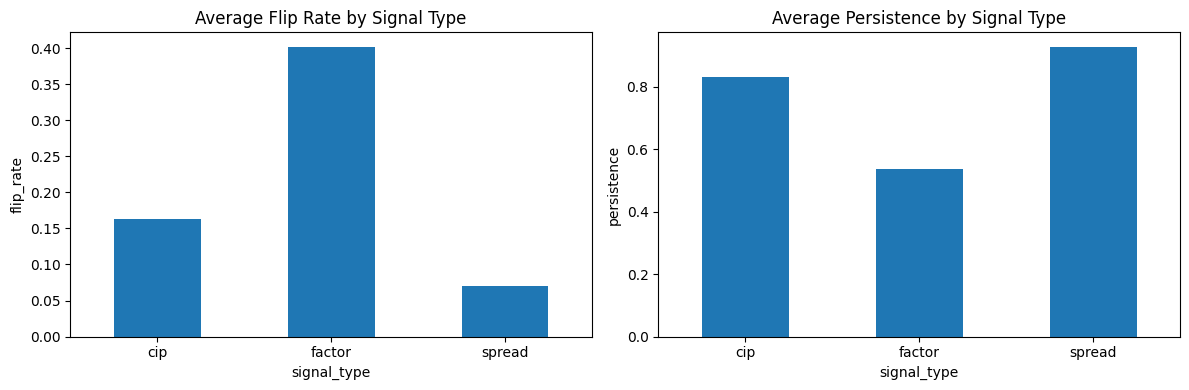

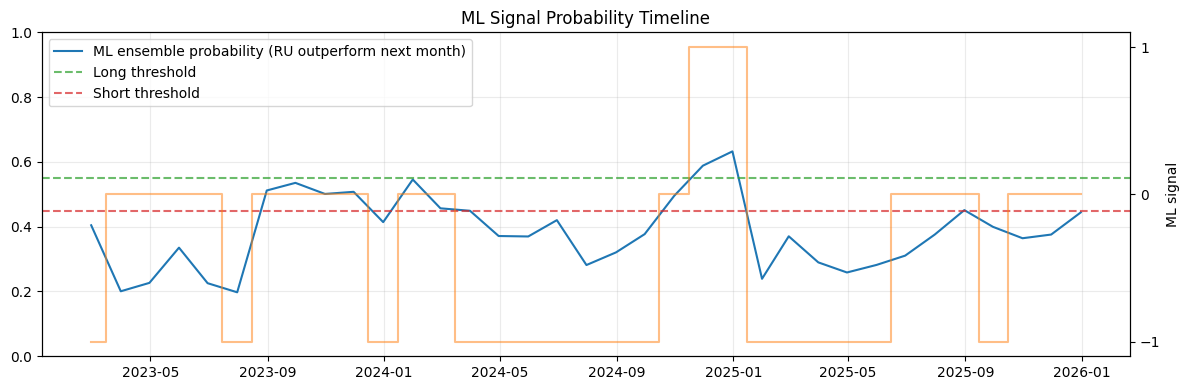

In [17]:
# Visualize stability by signal family + ML probability dynamics
if not diag.empty:
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    by_type = diag.groupby('signal_type')[['flip_rate', 'persistence']].mean()
    by_type['flip_rate'].plot(kind='bar', ax=ax[0], title='Average Flip Rate by Signal Type', rot=0)
    by_type['persistence'].plot(kind='bar', ax=ax[1], title='Average Persistence by Signal Type', rot=0)
    ax[0].set_ylabel('flip_rate')
    ax[1].set_ylabel('persistence')
    plt.tight_layout()
    plt.show()

if not ml_signals.empty and {'proba_ensemble', 'ml_signal'}.issubset(ml_signals.columns):
    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.plot(ml_signals['date'], ml_signals['proba_ensemble'], label='ML ensemble probability (RU outperform next month)', color='tab:blue')
    ax1.axhline(0.55, linestyle='--', color='tab:green', alpha=0.7, label='Long threshold')
    ax1.axhline(0.45, linestyle='--', color='tab:red', alpha=0.7, label='Short threshold')
    ax1.set_ylim(0, 1)
    ax1.set_title('ML Signal Probability Timeline')
    ax1.legend(loc='upper left')
    ax1.grid(alpha=0.25)

    ax2 = ax1.twinx()
    ax2.step(ml_signals['date'], ml_signals['ml_signal'], where='mid', color='tab:orange', alpha=0.5, label='ML signal')
    ax2.set_yticks([-1, 0, 1])
    ax2.set_ylabel('ML signal')
    plt.tight_layout()
    plt.show()

## Notes

- This notebook now includes **actual ML trading signals** with walk-forward evaluation and portfolio metrics.
- The `tab_6_4_advanced_methods.csv` block remains a diagnostic comparison (AER proxy / regime DNS), not a direct trading backtest.

In [18]:
# Major results summary (signals: classical vs ML)
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
PROCESSED = ROOT / 'data' / 'processed'
TABLES = ROOT / 'project report' / 'tables'

pf_path = PROCESSED / 'portfolio_backtest_summary.csv'
ml_pf_path = PROCESSED / 'ml_backtest_summary.csv'
ml_diag_path = PROCESSED / 'ml_signals_diagnostics.csv'
diag_path = PROCESSED / 'signals_latest_diagnostics.csv'
adv_path = TABLES / 'tab_6_4_advanced_methods.csv'

missing = [p for p in [pf_path, ml_pf_path, ml_diag_path, diag_path] if not p.exists()]
if missing:
    display(Markdown('**Major-results summary unavailable:** some signal/backtest artifacts are missing.'))
else:
    pf = pd.read_csv(pf_path)
    ml_pf = pd.read_csv(ml_pf_path)
    ml_diag = pd.read_csv(ml_diag_path)
    diag = pd.read_csv(diag_path)

    classical_row = pf[pf['strategy'] == 'strategy'].head(1)
    ml_row = ml_pf[ml_pf['strategy'] == 'ml_strategy'].head(1)

    classical_summary = {
        'family': 'Classical (spread/cip/factor)',
        'ann_sharpe': float(classical_row['ann_sharpe'].iloc[0]) if not classical_row.empty else np.nan,
        'max_drawdown': float(classical_row['max_drawdown'].iloc[0]) if not classical_row.empty else np.nan,
        'var95_empirical': float(classical_row['var95_empirical'].iloc[0]) if not classical_row.empty else np.nan,
        'mean_return': float(classical_row['mean_return'].iloc[0]) if not classical_row.empty else np.nan,
        'active_pct': float(diag['active_pct'].mean()) if not diag.empty else np.nan,
    }
    ml_summary = {
        'family': 'ML (logit + random forest ensemble)',
        'ann_sharpe': float(ml_row['ann_sharpe'].iloc[0]) if not ml_row.empty else np.nan,
        'max_drawdown': float(ml_row['max_drawdown'].iloc[0]) if not ml_row.empty else np.nan,
        'var95_empirical': float(ml_row['var95_empirical'].iloc[0]) if not ml_row.empty else np.nan,
        'mean_return': float(ml_row['mean_return'].iloc[0]) if not ml_row.empty else np.nan,
        'active_pct': float(ml_row['active_pct'].iloc[0]) if (not ml_row.empty and 'active_pct' in ml_row.columns) else np.nan,
    }

    cmp = pd.DataFrame([classical_summary, ml_summary])

    display(Markdown('## Major Results — Classical vs ML Signals'))
    display(cmp.round(4))

    if {'metric', 'value'}.issubset(ml_diag.columns):
        md = dict(zip(ml_diag['metric'], ml_diag['value']))
        ml_diag_summary = pd.DataFrame([
            {
                'n_predictions': md.get('n_predictions', np.nan),
                'trade_rate': md.get('trade_rate', np.nan),
                'accuracy': md.get('accuracy', np.nan),
                'f1': md.get('f1', np.nan),
                'roc_auc': md.get('roc_auc', np.nan),
                'directional_hit_when_active': md.get('directional_hit_when_active', np.nan),
            }
        ])
        display(Markdown('### ML diagnostic quality metrics'))
        display(ml_diag_summary.round(4))

if adv_path.exists():
    adv = pd.read_csv(adv_path)
    display(Markdown('### Advanced methods diagnostic block (non-trading reference)'))
    display(adv)

## Major Results — Classical vs ML Signals

,family,ann_sharpe,max_drawdown,var95_empirical,mean_return,active_pct
0,Classical (spread/cip/factor),-0.3133,-0.0605,0.0061,-0.0003,0.2618
1,ML (logit + random forest ensemble),0.1463,-0.0353,0.0093,0.0002,0.5143


### ML diagnostic quality metrics

,n_predictions,trade_rate,accuracy,f1,roc_auc,directional_hit_when_active
0,35.0,0.5143,0.6,0.25,0.4497,0.6875


### Advanced methods diagnostic block (non-trading reference)

,Method,Metric,Value,Notes
0,NS_baseline,RMSE_mean,0.141584,In-sample overall RMSE
1,AER_proxy,Objective_mean,0.025394,MSE + lambda * curvature penalty
2,AER_proxy,Penalty_mean,0.018732,Average curvature smoothness penalty
3,Regime_DNS,1step_RMSE_last,0.251929,Status=fitted; macro=global_indicators_DGS10
